# Analysis — Does Medicare Get What It Pays For?

This notebook turns the four gold tables into the project's headline findings. Each section answers one analytical question, shows the supporting data, and states what I conclude — including where the data is messier than a clean story would like.

The four analyses:

1. **The highest-spending providers** — who they are, and a real data anomaly worth understanding
2. **Spending variation by specialty** — how concentrated spending is within each specialty
3. **Geographic variation** — which states cost the most, and whether that buys better quality
4. **The cost-quality question** — the central scatter: at the hospital level, does higher spending correlate with better outcomes?

The short version of the answer, which the rest of this notebook supports: **no, not in any straightforward way.** Spending and quality are only weakly related, and a large share of hospitals are "value-mismatched" — either paying a lot for mediocre outcomes or achieving good outcomes at modest cost.

In [0]:
# Setup: imports and constants

from pyspark.sql import functions as F

CATALOG = "medicare_provider_quality"
GOLD_SCHEMA = "gold"

spark.sql(f"USE CATALOG {CATALOG}")
spark.sql(f"USE SCHEMA {GOLD_SCHEMA}")

# This notebook reads only from gold — the analytical tables are already built
print(f"Reading from: {CATALOG}.{GOLD_SCHEMA}")
print("Gold tables available:")
spark.sql(f"SHOW TABLES IN {CATALOG}.{GOLD_SCHEMA}").show(truncate=False)

Reading from: medicare_provider_quality.gold
Gold tables available:
+--------+-------------------------+-----------+
|database|tableName                |isTemporary|
+--------+-------------------------+-----------+
|gold    |hospital_value_scorecard |false      |
|gold    |provider_spending_summary|false      |
|gold    |specialty_benchmarks     |false      |
|gold    |state_spending_quality   |false      |
+--------+-------------------------+-----------+



## 1. The Highest-Spending Providers — and a Data Anomaly Worth Understanding

The obvious first question: who does Medicare pay the most? The answer turns out to be more interesting than a simple ranking, because the top of the list reveals a structural feature of how Medicare billing data works.

### What I expected vs. what the data shows

I expected the top spenders to be high-reimbursement specialists — oncologists administering expensive drugs, cardiac surgeons, ophthalmologists doing high volumes of cataract surgery. Some of that is there. But the very top of the list is dominated by something else: a cluster of Nurse Practitioners in Arizona, each billing Medicare tens of millions of dollars.

### Why this happens

A single nurse practitioner billing $135M is not one person seeing patients. It reflects how Medicare's billing structure allows organizational entities — large home-health, telehealth, or chronic-care-management operations — to bill under a single supervising provider's NPI. The published data aggregates all of that billing under the supervising NP's identifier. CMS has investigated some of these arrangements.

### Why I'm showing it instead of hiding it

I could have filtered these out and presented a cleaner "top providers" list. I chose not to, because the anomaly is genuinely informative: anyone working with Medicare provider data needs to know this pattern exists, or they'll draw wrong conclusions about individual physician earnings. The honest finding is "the raw top-spenders list is dominated by organizational billing aggregation, and here's how to recognize it."

For the cost-quality analysis later in this notebook, I do filter/cap these outliers — but there the goal is a readable correlation, and I document that choice when I make it.

In [0]:
# Top 20 highest-spending individual providers nationally
# This is the raw, unfiltered view — the anomaly is the point

top_spenders = spark.sql("""
    SELECT
        payment_rank_nationwide AS rank,
        last_or_org_name AS last_name,
        first_name,
        primary_specialty AS specialty,
        primary_state AS state,
        ROUND(total_medicare_payment / 1e6, 1) AS payment_millions,
        total_services,
        ROUND(avg_payment_per_service, 0) AS per_service
    FROM provider_spending_summary
    ORDER BY payment_rank_nationwide
    LIMIT 20
""")

top_spenders.show(20, truncate=False)

# Count how many of the top 50 are Nurse Practitioners in Arizona — quantify the anomaly
anomaly_count = spark.sql("""
    SELECT COUNT(*) AS np_az_in_top50
    FROM (
        SELECT primary_specialty, primary_state
        FROM provider_spending_summary
        ORDER BY payment_rank_nationwide
        LIMIT 50
    )
    WHERE primary_specialty = 'Nurse Practitioner'
      AND primary_state = 'AZ'
""").collect()[0]["np_az_in_top50"]

print(f"\nOf the top 50 highest-paid providers nationally, "
      f"{anomaly_count} are Nurse Practitioners in Arizona.")

+----+------------+----------+----------------------------------+-----+----------------+--------------+-----------+
|rank|last_name   |first_name|specialty                         |state|payment_millions|total_services|per_service|
+----+------------+----------+----------------------------------+-----+----------------+--------------+-----------+
|1   |Denny       |Ira       |Nurse Practitioner                |AZ   |135.3           |154796.0      |874.0      |
|2   |Kinds       |Jorge     |Nurse Practitioner                |AZ   |123.9           |133990.0      |924.0      |
|3   |Goss        |Keith     |Podiatry                          |AZ   |91.3            |106420.0      |858.0      |
|4   |Ching       |Carlos    |Nurse Practitioner                |AZ   |62.9            |69121.0       |911.0      |
|5   |Jameson     |Bethany   |Nurse Practitioner                |AZ   |49.9            |50051.0       |997.0      |
|6   |Jeng        |Aaron     |Internal Medicine                 |CA   |4

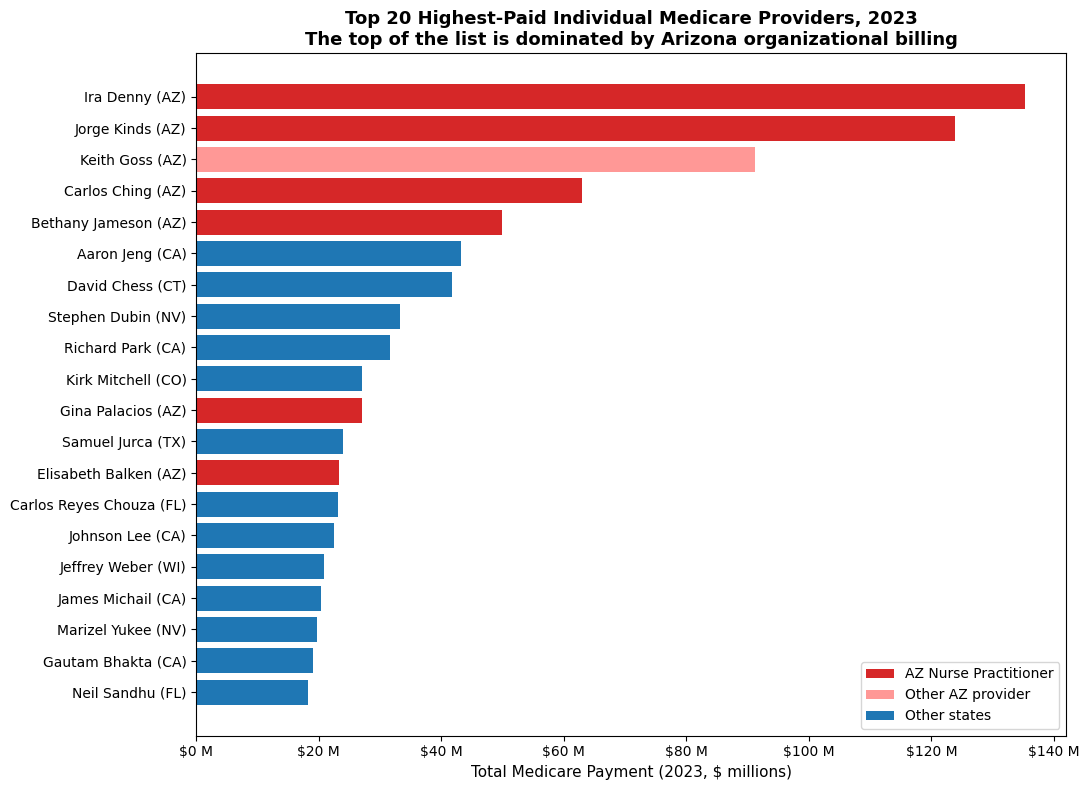

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Pull top 20 into pandas for plotting
top20_pd = spark.sql("""
    SELECT
        payment_rank_nationwide AS rank,
        CONCAT(first_name, ' ', last_or_org_name, ' (', primary_state, ')') AS provider_label,
        primary_specialty AS specialty,
        primary_state AS state,
        total_medicare_payment / 1e6 AS payment_millions
    FROM provider_spending_summary
    ORDER BY payment_rank_nationwide
    LIMIT 20
""").toPandas()

# Flag the AZ Nurse Practitioner pattern for coloring
def categorize(row):
    if row['specialty'] == 'Nurse Practitioner' and row['state'] == 'AZ':
        return 'AZ Nurse Practitioner'
    elif row['state'] == 'AZ':
        return 'Other AZ provider'
    else:
        return 'Other states'

top20_pd['category'] = top20_pd.apply(categorize, axis=1)

color_map = {
    'AZ Nurse Practitioner': '#d62728',   # red — the headline anomaly
    'Other AZ provider':     '#ff9896',   # light red
    'Other states':          '#1f77b4',   # blue
}
colors = top20_pd['category'].map(color_map)

# Plot (reverse order so rank 1 is at top)
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top20_pd['provider_label'][::-1], top20_pd['payment_millions'][::-1],
        color=colors[::-1])

ax.set_xlabel('Total Medicare Payment (2023, $ millions)', fontsize=11)
ax.set_title('Top 20 Highest-Paid Individual Medicare Providers, 2023\n'
             'The top of the list is dominated by Arizona organizational billing',
             fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%d M'))
plt.tight_layout()
plt.show()

## 2. Spending Variation by Specialty

The first analysis showed that individual outliers distort the top of the provider list. This section asks the same question one level up: which specialties have the most concentrated spending, and what does that concentration tell us?

### Two different questions about specialty spending

There are two ways to ask "which specialties cost the most," and they give different answers:

1. **What does a typical provider in this specialty bill?** — answered by the median. This is the honest "what does a cardiologist vs. a family doctor actually bill Medicare" comparison.

2. **How concentrated is spending within the specialty?** — answered by the top-1% concentration ratio. This exposes whether a specialty's total spending is spread evenly across its providers or dominated by a small number of high-billers.

### Why the concentration ratio is the more interesting metric

For most physician specialties, the top 1% of providers account for 10-15% of the specialty's total Medicare spending — some concentration, but not extreme. When a specialty shows materially higher concentration, it's a signal that something structural is happening: organizational billing aggregation, or a small number of very-high-volume operations.

Nurse Practitioner is the clearest example. Its top 1% accounts for ~30% of all NP Medicare spending — double the normal range. That's the same Arizona organizational-billing pattern from Analysis 1, now visible as a specialty-level statistic rather than a list of individual names.

I think the concentration ratio is genuinely useful beyond this project: it's a quick screening metric for "which specialties in a Medicare dataset warrant a closer look for billing-structure effects."

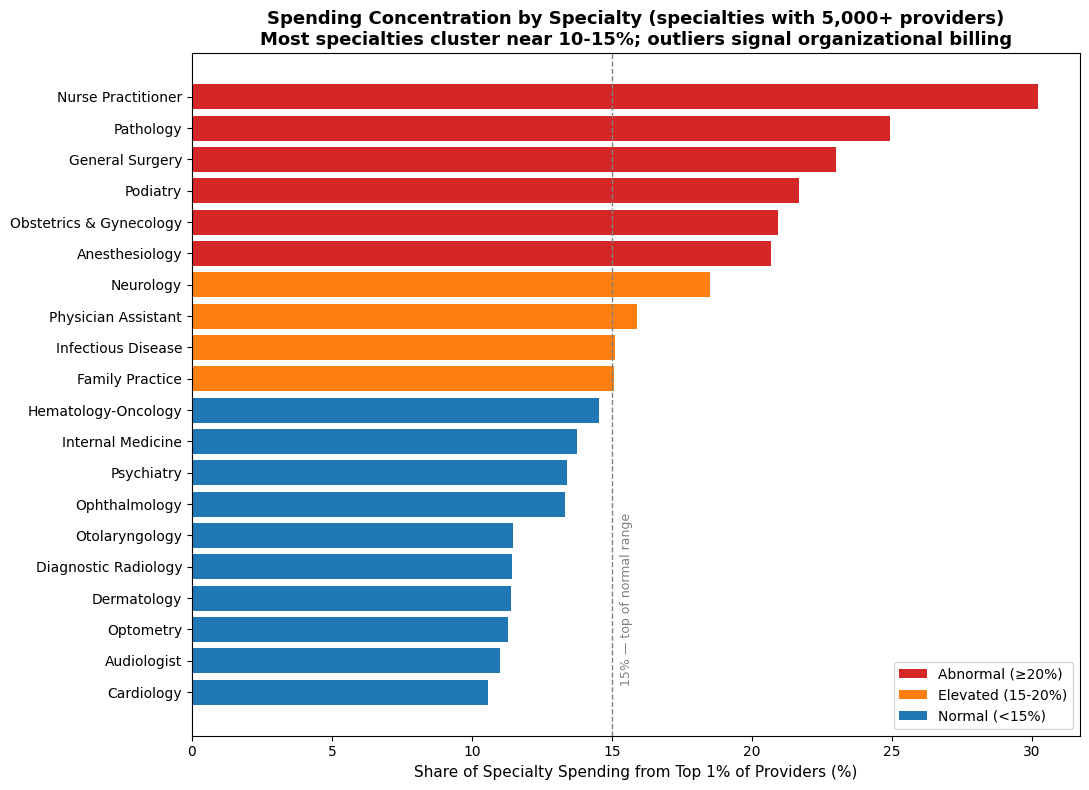

              specialty  provider_count  median_payment  top1pct_share
     Nurse Practitioner          174679         12270.0          30.21
              Pathology           11952         41624.0          24.93
        General Surgery           19058         19576.0          23.00
               Podiatry           15192         61230.0          21.67
Obstetrics & Gynecology           17962          4719.0          20.93
         Anesthesiology           34189         10658.0          20.70
              Neurology           15573         36447.0          18.50
    Physician Assistant           94996         11852.0          15.89
     Infectious Disease            6052         36943.0          15.11
        Family Practice           78514         30159.0          15.06
    Hematology-Oncology            8675         64620.0          14.53
      Internal Medicine           88702         44994.0          13.77
             Psychiatry           18253         14987.0          13.40
      

In [0]:
import matplotlib.pyplot as plt

# Pull the specialties with enough providers to be meaningful, sorted by concentration
concentration_pd = spark.sql("""
    SELECT
        specialty,
        provider_count,
        ROUND(median_payment_per_provider, 0) AS median_payment,
        spending_concentration_top1pct_share AS top1pct_share
    FROM specialty_benchmarks
    WHERE provider_count >= 5000        -- only specialties with substantial provider counts
    ORDER BY spending_concentration_top1pct_share DESC
    LIMIT 20
""").toPandas()

# Color by concentration level: abnormal (>=20%) vs elevated (15-20%) vs normal (<15%)
def conc_color(share):
    if share >= 20:
        return '#d62728'   # red — abnormal
    elif share >= 15:
        return '#ff7f0e'   # orange — elevated
    else:
        return '#1f77b4'   # blue — normal

colors = concentration_pd['top1pct_share'].apply(conc_color)

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(concentration_pd['specialty'][::-1],
        concentration_pd['top1pct_share'][::-1],
        color=colors[::-1])

# Reference line at 15% (the top of the "normal" range)
ax.axvline(x=15, color='gray', linestyle='--', linewidth=1)
ax.text(15.3, 0.3, '15% — top of normal range', fontsize=9, color='gray', rotation=90)

ax.set_xlabel('Share of Specialty Spending from Top 1% of Providers (%)', fontsize=11)
ax.set_title('Spending Concentration by Specialty (specialties with 5,000+ providers)\n'
             'Most specialties cluster near 10-15%; outliers signal organizational billing',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Abnormal (≥20%)'),
    Patch(facecolor='#ff7f0e', label='Elevated (15-20%)'),
    Patch(facecolor='#1f77b4', label='Normal (<15%)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# Also print the table for the record
concentration_pd.to_string(index=False)
print(concentration_pd.to_string(index=False))

## 3. Geographic Variation — Does Higher State Spending Buy Better Quality?

Moving from individual providers and specialties to geography. The question: do states where Medicare spends more per beneficiary actually have better hospital quality?

### The two-part finding

The state-level data shows two things clearly:

1. **Spending per beneficiary varies enormously across states** — from under $100 to over $170 per beneficiary, a range of roughly 70%.

2. **Quality varies very little across states** — composite mortality, readmission rates, and patient experience scores stay within a narrow band regardless of how much a state spends.

Put together: the states that spend the most are not meaningfully healthier. This is the geographic version of the project's central question, and the answer is the same as it will be at the hospital level — spending and quality are weakly related at best.

### The contrast that makes the point

Two states make the disconnect concrete:

- **Arizona** spends about $170 per beneficiary — the highest of any large state — and ranks middle-of-the-pack on quality. (Recall from Analysis 1 that Arizona's high spending is partly the organizational-billing pattern.)
- **Virginia** spends about $116 per beneficiary — well below Arizona — yet has the highest average hospital star rating of the states examined.

If higher spending reliably bought better quality, Arizona and Virginia would be reversed. They aren't.

### A caveat on causation

This is a correlation at the state level, not a causal claim. States differ in population health, demographics, rurality, and dozens of other factors that affect both spending and outcomes. The honest takeaway is narrow: **at the state level, higher Medicare spending does not visibly correspond to better hospital quality.** Why that's true is a harder question this data can't answer alone.

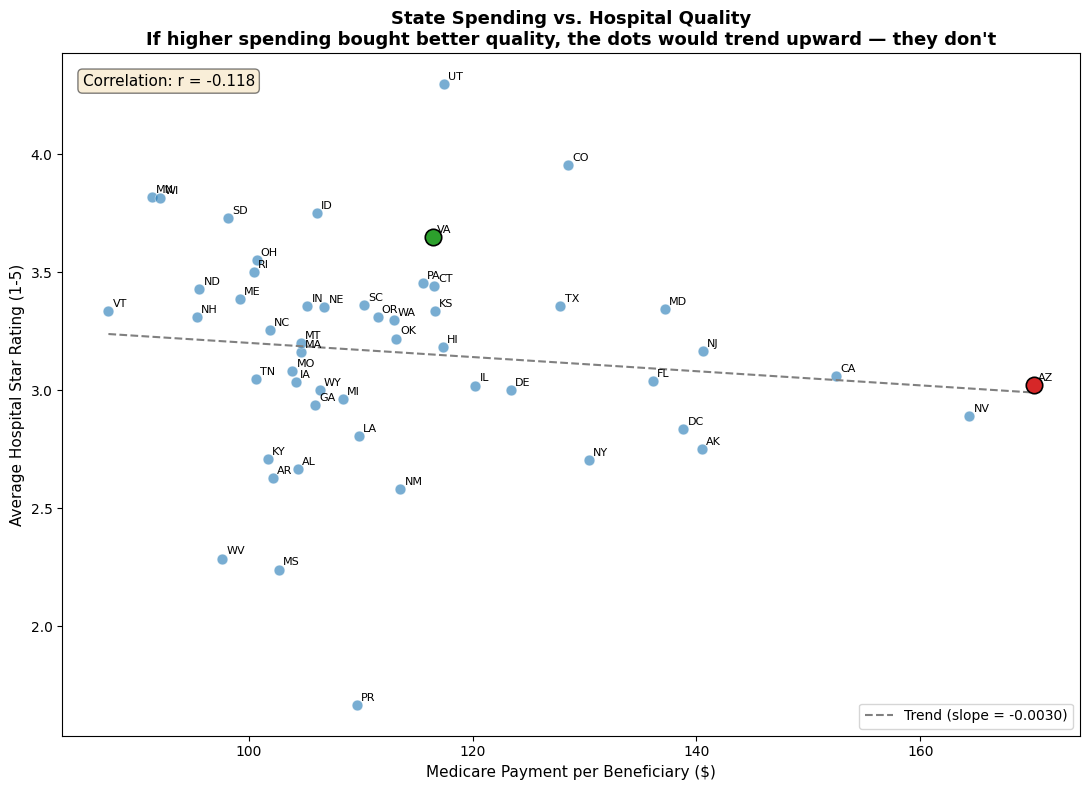


Correlation between state spending per beneficiary and avg hospital star rating: r = -0.118


In [0]:
import matplotlib.pyplot as plt

# Pull state-level spending and quality
state_pd = spark.sql("""
    SELECT
        state,
        payment_per_beneficiary,
        avg_hospital_overall_rating,
        avg_mort_30_ami,
        active_provider_count
    FROM state_spending_quality
    WHERE payment_per_beneficiary IS NOT NULL
      AND avg_hospital_overall_rating IS NOT NULL
      AND active_provider_count >= 1000   -- drop tiny territories with unstable averages
""").toPandas()

fig, ax = plt.subplots(figsize=(11, 8))

# Scatter: spending (x) vs avg star rating (y)
ax.scatter(state_pd['payment_per_beneficiary'],
           state_pd['avg_hospital_overall_rating'],
           s=60, color='#1f77b4', alpha=0.6, edgecolors='white', linewidth=0.5)

# Label every state
for _, row in state_pd.iterrows():
    ax.annotate(row['state'],
                (row['payment_per_beneficiary'], row['avg_hospital_overall_rating']),
                fontsize=8, xytext=(3, 3), textcoords='offset points')

# Highlight AZ and VA — the contrast pair
for st, color in [('AZ', '#d62728'), ('VA', '#2ca02c')]:
    r = state_pd[state_pd['state'] == st]
    if not r.empty:
        ax.scatter(r['payment_per_beneficiary'], r['avg_hospital_overall_rating'],
                   s=140, color=color, edgecolors='black', linewidth=1.2, zorder=5)

ax.set_xlabel('Medicare Payment per Beneficiary ($)', fontsize=11)
ax.set_ylabel('Average Hospital Star Rating (1-5)', fontsize=11)
ax.set_title('State Spending vs. Hospital Quality\n'
             'If higher spending bought better quality, the dots would trend upward — they don\'t',
             fontsize=13, fontweight='bold')

# Add a trend line to show how flat the relationship is
import numpy as np
z = np.polyfit(state_pd['payment_per_beneficiary'], state_pd['avg_hospital_overall_rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(state_pd['payment_per_beneficiary'].min(),
                     state_pd['payment_per_beneficiary'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='gray', linewidth=1.5,
        label=f'Trend (slope = {z[0]:.4f})')

# Correlation coefficient
corr = state_pd['payment_per_beneficiary'].corr(state_pd['avg_hospital_overall_rating'])
ax.text(0.02, 0.97, f'Correlation: r = {corr:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nCorrelation between state spending per beneficiary and avg hospital star rating: r = {corr:.3f}")

## 4. The Central Question — Cost vs. Quality at the Hospital Level

This is the analysis the whole project builds toward. At the hospital level: does higher physician spending intensity correspond to better patient outcomes?

### The metric choices

- **X axis — spending intensity:** average Medicare payment per beneficiary across the providers matched to each hospital (via the bridge from Phase 3).
- **Y axis — quality:** composite mortality (unweighted average of the 6 mortality measures). Lower is better, so a "you get what you pay for" world would show a downward slope — more spending, lower mortality.

### The outlier handling, and why I'm doing it

A small number of hospitals have spending-per-beneficiary values inflated by the same organizational-billing pattern from Analysis 1 — a matched provider whose NPI carries aggregated billing. Left in, these few hospitals stretch the X axis so far that the main cloud of hospitals compresses into an unreadable smear.

For this chart, I cap the spending axis at the 95th percentile. This keeps every hospital in the dataset for the correlation calculation but makes the visual readable. I considered dropping the outlier hospitals entirely — I chose capping the axis instead because it's less destructive (no hospitals removed) and the capped points are still visible at the right edge. This is a presentation choice, documented here, not a change to the underlying data.

### The four-quadrant framing

I split hospitals into four groups by whether they're above or below the national median on each axis:

- **Low cost, high quality** — the ideal: good outcomes, modest spending
- **High cost, high quality** — good outcomes, but expensive
- **Low cost, low quality** — cheap, but poor outcomes
- **High cost, low quality** — the worst value: expensive AND poor outcomes

If spending bought quality, hospitals would cluster in the "high cost, high quality" and "low cost, low quality" diagonal. The finding from the gold table was that the four quadrants are roughly equal — which means spending and quality are largely independent.

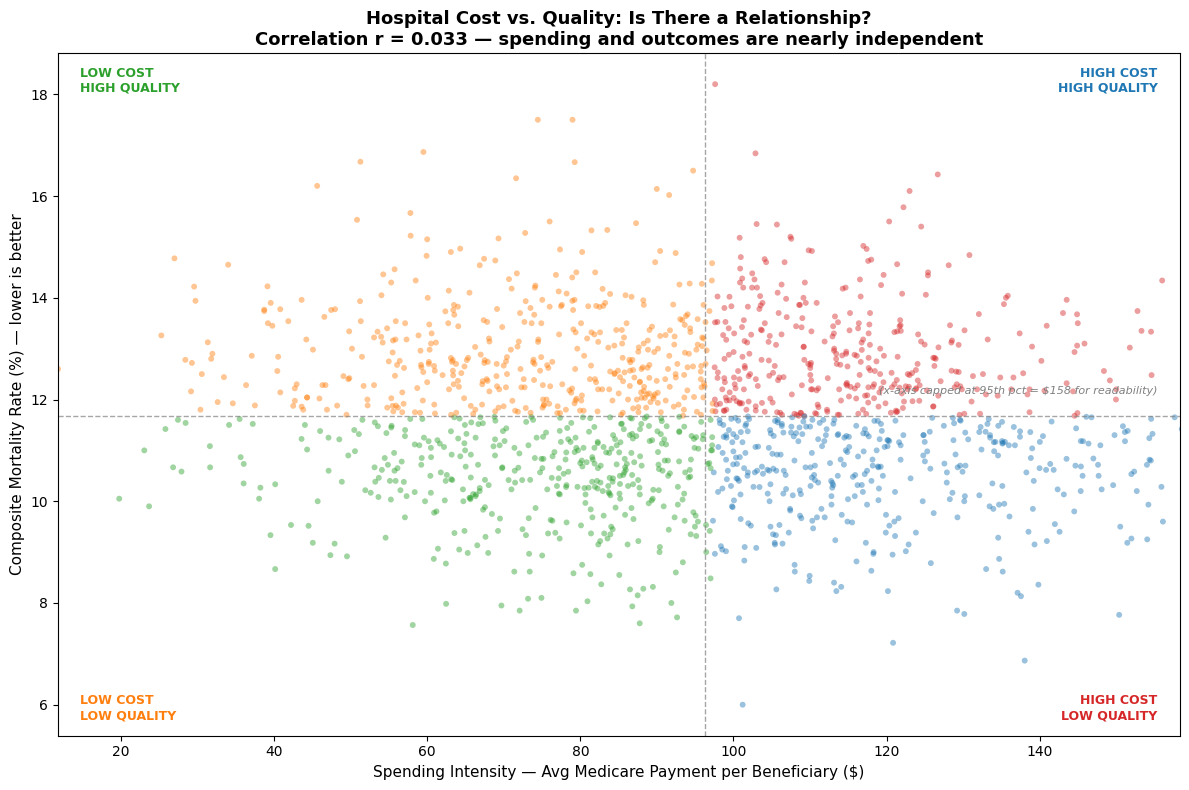

Correlation (full data, no cap): r = 0.033
National median spending intensity: $96
National median composite mortality: 11.68%


In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Pull hospital scorecard data — only rows with both metrics populated
hosp_pd = spark.sql("""
    SELECT
        hospital_name,
        state,
        avg_payment_per_beneficiary,
        composite_mortality,
        value_quadrant,
        hospital_overall_rating
    FROM hospital_value_scorecard
    WHERE avg_payment_per_beneficiary IS NOT NULL
      AND composite_mortality IS NOT NULL
""").toPandas()

# Correlation on the FULL data (before any capping — capping is visual only)
corr = hosp_pd['avg_payment_per_beneficiary'].corr(hosp_pd['composite_mortality'])

# Cap the x-axis at 95th percentile for readability
x_cap = hosp_pd['avg_payment_per_beneficiary'].quantile(0.95)

# Median reference lines (national medians used for quadrant assignment)
med_spending = hosp_pd['avg_payment_per_beneficiary'].median()
med_mortality = hosp_pd['composite_mortality'].median()

# Color by quadrant
quadrant_colors = {
    'low_cost_high_quality':  '#2ca02c',   # green — the ideal
    'high_cost_high_quality': '#1f77b4',   # blue
    'low_cost_low_quality':   '#ff7f0e',   # orange
    'high_cost_low_quality':  '#d62728',   # red — worst value
}
colors = hosp_pd['value_quadrant'].map(quadrant_colors)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(hosp_pd['avg_payment_per_beneficiary'], hosp_pd['composite_mortality'],
           s=18, c=colors, alpha=0.45, edgecolors='none')

# Median reference lines
ax.axvline(x=med_spending, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=med_mortality, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Quadrant labels in the corners
ax.text(0.02, 0.02, 'LOW COST\nLOW QUALITY', transform=ax.transAxes,
        fontsize=9, color='#ff7f0e', fontweight='bold', va='bottom', ha='left')
ax.text(0.98, 0.02, 'HIGH COST\nLOW QUALITY', transform=ax.transAxes,
        fontsize=9, color='#d62728', fontweight='bold', va='bottom', ha='right')
ax.text(0.02, 0.98, 'LOW COST\nHIGH QUALITY', transform=ax.transAxes,
        fontsize=9, color='#2ca02c', fontweight='bold', va='top', ha='left')
ax.text(0.98, 0.98, 'HIGH COST\nHIGH QUALITY', transform=ax.transAxes,
        fontsize=9, color='#1f77b4', fontweight='bold', va='top', ha='right')

ax.set_xlim(hosp_pd['avg_payment_per_beneficiary'].min(), x_cap)
ax.set_xlabel('Spending Intensity — Avg Medicare Payment per Beneficiary ($)', fontsize=11)
ax.set_ylabel('Composite Mortality Rate (%) — lower is better', fontsize=11)
ax.set_title('Hospital Cost vs. Quality: Is There a Relationship?\n'
             f'Correlation r = {corr:.3f} — spending and outcomes are nearly independent',
             fontsize=13, fontweight='bold')

# Note about the cap
ax.text(0.98, 0.5, f'(x-axis capped at 95th pct = ${x_cap:.0f} for readability)',
        transform=ax.transAxes, fontsize=8, color='gray', ha='right', style='italic')

plt.tight_layout()
plt.show()

print(f"Correlation (full data, no cap): r = {corr:.3f}")
print(f"National median spending intensity: ${med_spending:.0f}")
print(f"National median composite mortality: {med_mortality:.2f}%")

## Conclusion — Does Medicare Get What It Pays For?

Four analyses, one consistent answer: **spending and quality are only weakly related, at every level examined.**

**What the analyses showed:**

1. **The top of the spending distribution is dominated by organizational billing**, not individual physician earnings. The highest-"paid" providers are mostly Arizona entities billing under a single NPI. Anyone using this data needs to recognize the pattern — the per-service cost is the tell.

2. **Spending concentration varies by specialty in informative ways.** Most physician specialties concentrate 10-15% of spending in their top 1%; a handful (Nurse Practitioner at 30%, plus Pathology, Anesthesiology, General Surgery) run much higher. High concentration flags organizational billing — sometimes benign (anesthesia groups), sometimes worth scrutiny.

3. **At the state level, spending and quality barely correlate (r = -0.118).** States that spend the most per beneficiary are not measurably healthier. Arizona spends the most and ranks middling; Virginia spends far less and ranks near the top.

4. **At the hospital level, spending and mortality are essentially independent (r = 0.033).** The four cost-quality quadrants are evenly populated — roughly half of hospitals are "value-mismatched," either paying a lot for poor outcomes or achieving good outcomes cheaply.

**The honest bottom line:**

In this data, higher Medicare spending does not reliably buy better quality. That finding is consistent across grain (state and hospital) and method (correlation and quadrant analysis), which makes it robust as a *description* of the data.

**What this analysis does NOT claim:**

- **Not causal.** Sicker populations cost more and have worse outcomes regardless of care quality. This data can't separate "spending doesn't help" from "high-need areas spend more and still struggle."
- **Not complete on quality.** Mortality is one dimension. A fuller picture would weight readmissions, patient experience, and safety together.
- **Bounded by the bridge.** The hospital-level analysis only covers hospitals where the address-matching bridge connected providers (62.6% of acute care hospitals), and is biased toward providers whose billing address matches their hospital exactly.

These limits are real, and the final report states them plainly. The value of the analysis is in showing — with reproducible code on real federal data — that the intuitive "you get what you pay for" assumption does not hold for Medicare spending and hospital quality.